# Do it yourself morning session
## Imports

Import point for point selection as the center and BoundingBox for corner coordinates input

In [1]:
import numpy as np
from datacube import Datacube
from odc.geo.geom import point, BoundingBox

In [2]:
from dask.distributed import Client

dask_client = Client()
dask_client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41195,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40167,Total threads: 2
Dashboard: http://127.0.0.1:41073/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:39157,


In [3]:
dc = Datacube()

## Coordinate input
### Using `BoundingBox`

In [4]:
lat1, lon1 = -5.70579702, 124.01522685
lat2, lon2 = -5.86482587, 123.81927526

# switch lat and long so that 1 is always less than 2
if lat1 > lat2:
    lat1, lat2 = lat2, lat1
if lon1 > lon2:
    lon1, lon2 = lon2, lon1

poly_box = BoundingBox(lon1, lat1, lon2, lat2)

poly_box.explore()

## Using point

Insert one coordinate at the center of you AOI and then use `point`

In [5]:
lat0, lon0 = -5.76092006, 123.92623932
aoi_center = point(lon0, lat0, crs="epsg:4326")

poly_buffer = aoi_center.buffer(0.1).boundingbox
poly_buffer.explore()

## Image processing

### Image queries

Insert date range, cloud cover, and band layer selections

In [6]:
date_query = ("2025")
cloud_cover_query = (5, 20)
band_layers = ["red", "green", "blue"]

### Showing number of datasets

In [7]:
datasets = dc.find_datasets(
    product="s2_l2a",
    time=date_query,
    lon=(poly_box.left, poly_box.right),
    lat=(poly_box.bottom, poly_box.top),
    cloud_cover=cloud_cover_query
)

print(f"Found {len(datasets)} datasets")

Querying product Product(name='s2_l2a', id_=9)


Found 18 datasets


### Load founded datasets

In [8]:
ds = dc.load(
    datasets=datasets,
    measurements=band_layers,
    dask_chunks={},
    resolution=20,
    output_crs=datasets[0].crs,
    lon=(poly_box.left, poly_box.right),
    lat=(poly_box.bottom, poly_box.top),
).compute()

ds

<xarray.Dataset> Size: 104MB
Dimensions:      (time: 18, y: 882, x: 1087)
Coordinates:
  * time         (time) datetime64[ns] 144B 2025-01-07T02:09:13.065000 ... 20...
  * y            (y) float64 7kB 9.369e+06 9.369e+06 ... 9.352e+06 9.352e+06
  * x            (x) float64 9kB 5.907e+05 5.907e+05 ... 6.124e+05 6.124e+05
    spatial_ref  int32 4B 32751
Data variables:
    red          (time, y, x) uint16 35MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    green        (time, y, x) uint16 35MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    blue         (time, y, x) uint16 35MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
Attributes:
    crs:           EPSG:32751
    grid_mapping:  spatial_ref

## Data visualisation

### Visualise all data

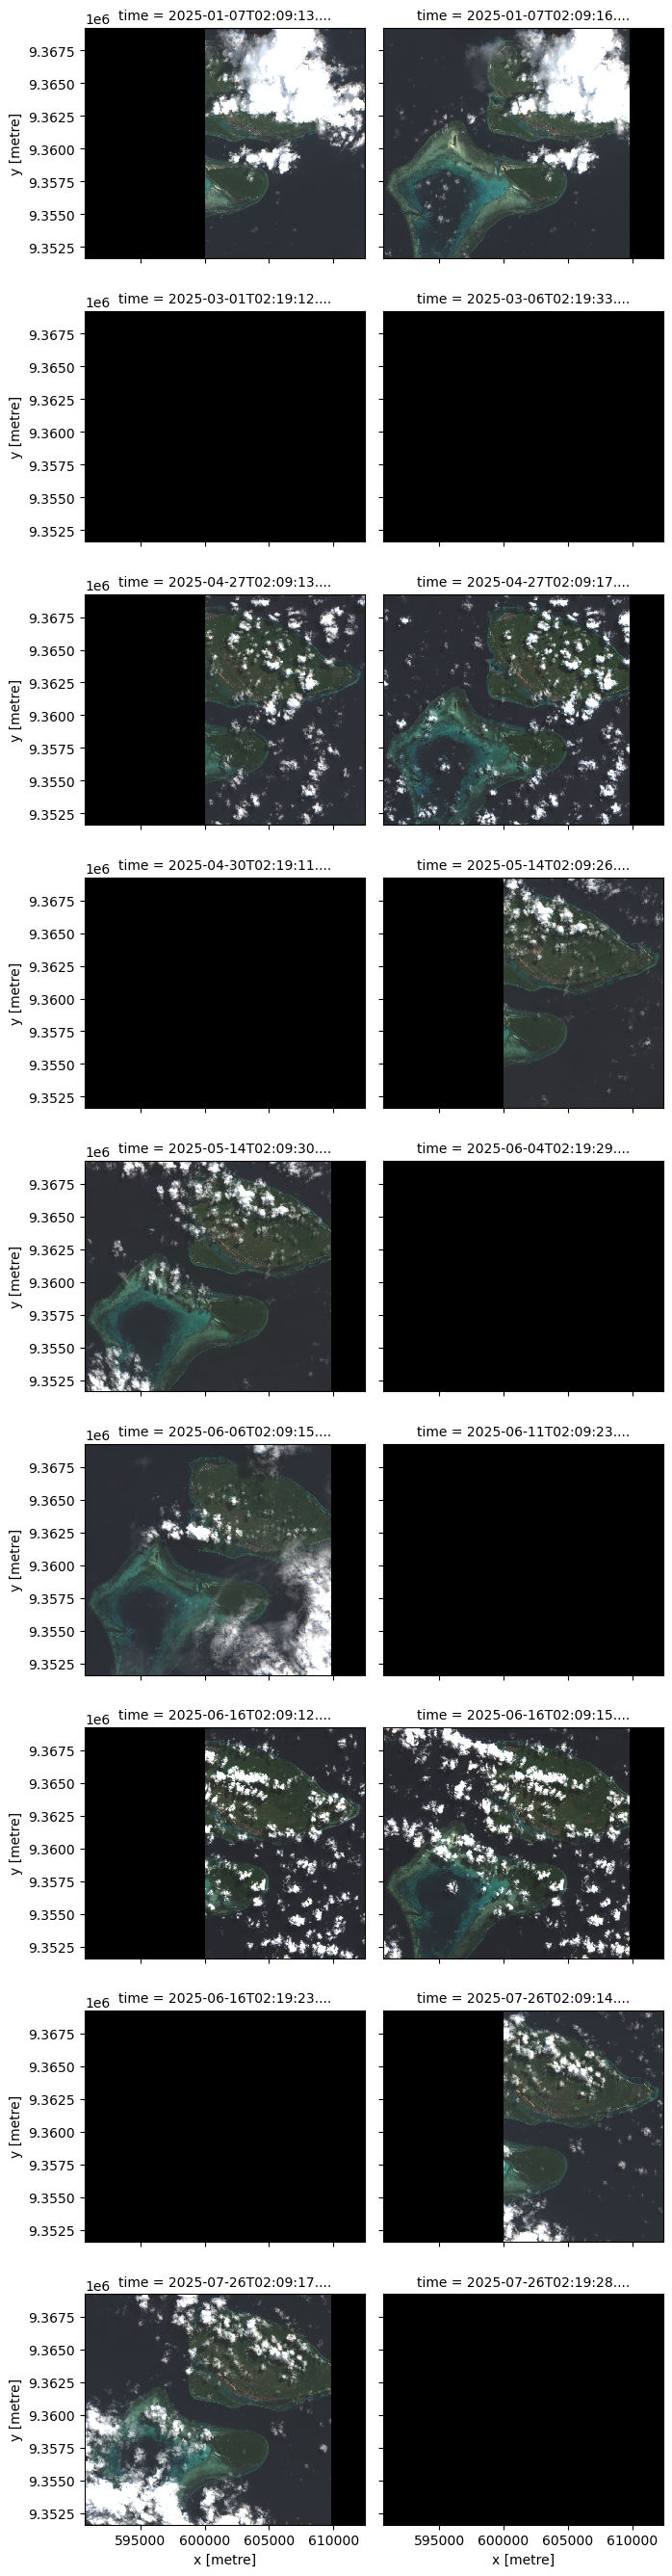

In [ ]:
ds.to_array().plot.imshow(col="time", col_wrap=2, robust=True)

### Select best image

In [ ]:
best_date = "2025-04-27"
best_image = ds.sel(time=best_date)
best_image = ds.isel(time=1).squeeze()
best_image

### Visualise best image

In [ ]:
visualisation = best_image.odc.to_rgba()

visualisation.odc.explore()

### Visualise stretched best image

In [ ]:
percentile_stretch = (1, 90)
rgb_array = best_image.to_array().values

stretch_vmin, stretch_vmax = np.nanpercentile(
    rgb_array, percentile_stretch
)
stretch_visualisation = best_image.odc.to_rgba(
    vmin=stretch_vmin, vmax=stretch_vmax
)
stretch_visualisation.odc.explore()

### Save stretched best image

In [ ]:
stretch_visualisation.od.write_cog("rifqi_site_tomia.tif")